# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Phan Gia Huy"  # TODO: Họ và tên
STUDENT_ID = "2510096"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Phan Gia Huy (2510096)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\MLIoT\Khóa hè ML&Python\HW\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
# Trừ row-wise maximum để tránh overflow
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
# Tính xác suất softmax
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)
# Dùng mean và std của tập train để scale cả hai tập
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
correct_mask = (predicted_classes == true_labels)
high_confidence_mask = (confidence_scores >= confidence_threshold)
# Review khi dự đoán sai hoặc confidence thấp
review_mask = ~(correct_mask & high_confidence_mask)
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
# Lật ngang ảnh (trục Width là axis=2 đối với định dạng B, H, W, C)
augmented_batch = np.flip(normalized_batch, axis=2).copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

1. Mỗi dòng đại diện cho một mẫu xe hơi (automobile) cụ thể trong bộ dữ liệu 1985 Auto Imports.
2. Ký hiệu missing value trong CSV là dấu `?`.
3. `symboling` thể hiện mức độ rủi ro bảo hiểm của xe, được đánh giá trên thang điểm từ -3 (rất an toàn) đến 3 (rủi ro cao).

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
df_clean = raw_df.replace('?', np.nan).copy()
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')
missing_by_column = df_clean.isnull().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**
- Không nên fill tất cả numeric columns bằng một giá trị (như 0 hay mean chung) vì mỗi cột đại diện cho một đơn vị, quy mô và đặc trưng phân phối hoàn toàn khác nhau (ví dụ: vòng tua máy peak_rpm hàng ngàn khác với bore chỉ vài inch).
- Với `price`, nên drop (xóa) các dòng thiếu. Lý do là vì bài toán EDA thường xoay quanh giá xe làm biến mục tiêu (target). Việc gán giá trị giả (fill) sẽ làm sai lệch cấu trúc phân phối của biến quan trọng nhất này.
- `normalized_losses` thiếu rất nhiều dữ liệu (41 dòng). Nếu ta drop cột này thì mất đi một biến có thể quan trọng cho phân tích rủi ro, nhưng nếu drop theo dòng thì sẽ làm mất đi một lượng lớn các mẫu xe, làm thu hẹp kích thước tập dữ liệu.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna().copy()
X_auto = analysis_df.to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
price_index = AUTO_FEATURES.index('price')
price_z = X_auto_scaled[:, price_index] 
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df.iloc[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
engine_arr = analysis_df['engine_size'].to_numpy()
price_arr = analysis_df['price'].to_numpy()
# Tính Pearson correlation matrix và lấy phần tử ngoài đường chéo
engine_price_corr = np.corrcoef(engine_arr, price_arr)[0, 1]
price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

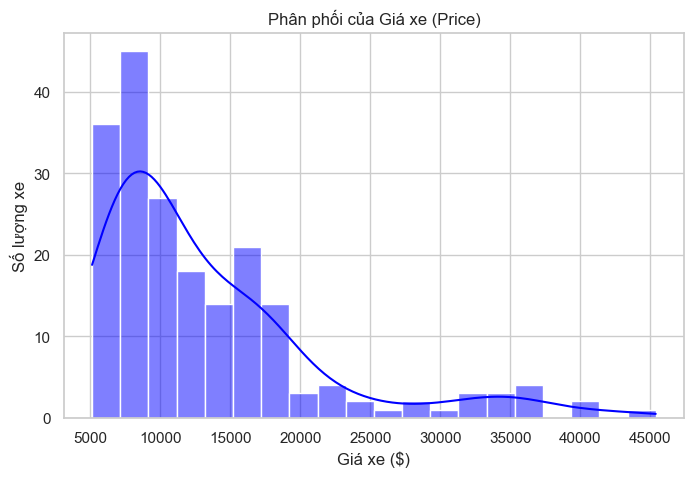

In [20]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['price'], kde=True, color='blue', bins=20)
plt.title("Phân phối của Giá xe (Price)")
plt.xlabel("Giá xe ($)")
plt.ylabel("Số lượng xe")
plt.show()

**Nhận xét:** 
Phân phối của giá xe lệch phải (right-skewed). Đa số các mẫu xe tập trung ở phân khúc giá rẻ (dưới 15,000 USD), chỉ có một số ít xe thuộc phân khúc hạng sang có giá rất cao trải dài đến hơn 40,000 USD.

## M2.2 Dataset có cân bằng theo body style không?

C:\Users\Phan Gia Huy\AppData\Local\Temp\ipykernel_4452\4058340338.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='body_style', palette='viridis')


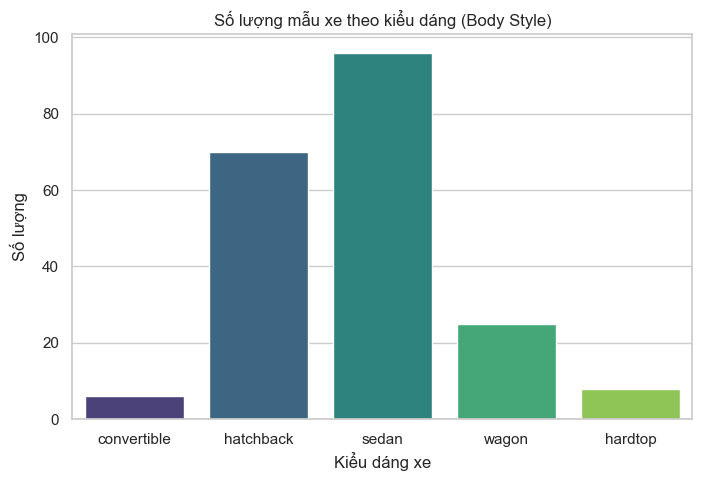

In [21]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='body_style', palette='viridis')
plt.title("Số lượng mẫu xe theo kiểu dáng (Body Style)")
plt.xlabel("Kiểu dáng xe")
plt.ylabel("Số lượng")
plt.show()

**Nhận xét:** 
Tập dữ liệu hoàn toàn mất cân bằng. Sedan và Hatchback chiếm đại đa số, trong khi Convertible và Hardtop có lượng mẫu cực kỳ ít, gây khó khăn nếu xây dựng mô hình dự đoán.

## M2.3 Price khác nhau theo body style ra sao?

C:\Users\Phan Gia Huy\AppData\Local\Temp\ipykernel_4452\860575266.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='body_style', y='price', palette='Set2')


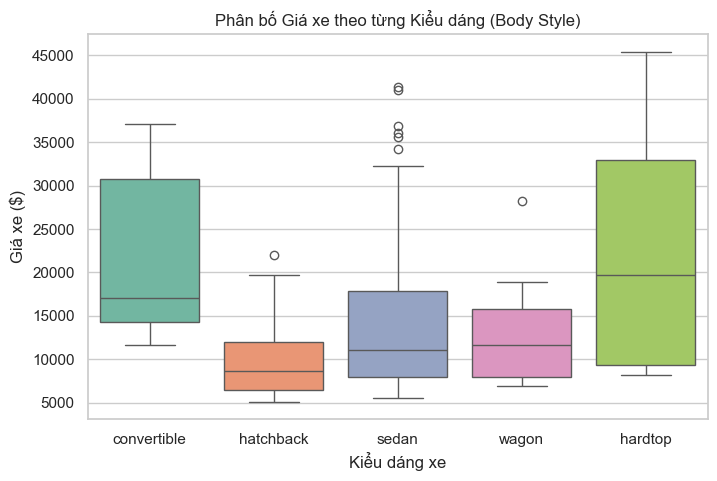

In [22]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='body_style', y='price', palette='Set2')
plt.title("Phân bố Giá xe theo từng Kiểu dáng (Body Style)")
plt.xlabel("Kiểu dáng xe")
plt.ylabel("Giá xe ($)")
plt.show()

**Nhận xét:** 
Xe kiểu dáng hardtop và convertible có mức giá trung bình cao nhất, phổ phân bố giá rộng. Sedan có nhiều outlier (xe giá cực cao so với mặt bằng chung của dòng sedan), trong khi hatchback có giá trung bình thấp nhất và phân bố hẹp.

## M2.4 Engine size liên quan thế nào tới price?

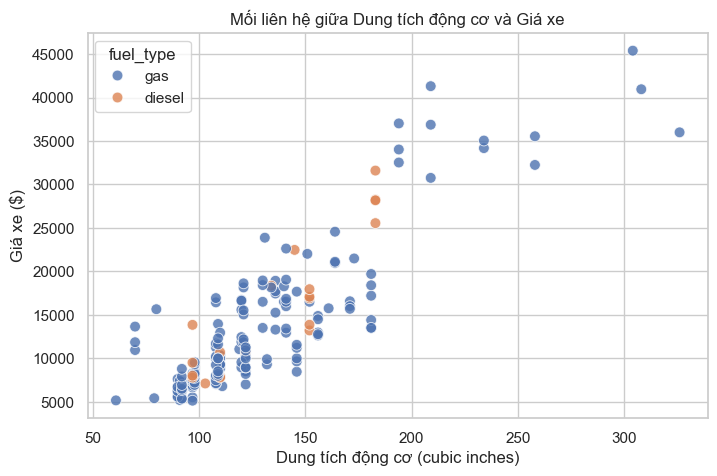

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', s=60, alpha=0.8)
plt.title("Mối liên hệ giữa Dung tích động cơ và Giá xe")
plt.xlabel("Dung tích động cơ (cubic inches)")
plt.ylabel("Giá xe ($)")
plt.show()

**Nhận xét:** 
Có một sự tương quan thuận cực kỳ rõ rệt: dung tích động cơ càng lớn thì giá xe càng đắt. Dữ liệu xe chạy bằng Diesel khá ít và đa phần tập trung ở phân khúc động cơ nhỏ-vừa (dưới 150 cubic inches).

## M2.5 Các feature numeric tương quan ra sao?

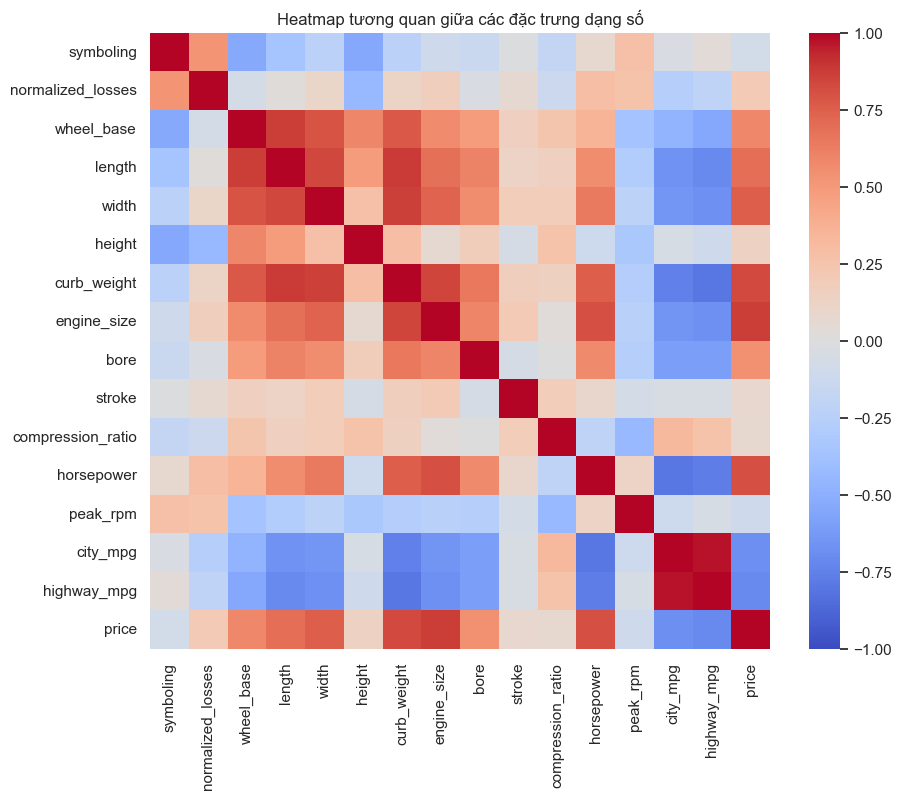

In [24]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(10, 8))
# Tính ma trận tương quan cho các biến số, loại bỏ NaN
corr = df_clean[NUMERIC_COLUMNS].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Heatmap tương quan giữa các đặc trưng dạng số")
plt.show()

**Nhận xét:** 
Giá xe (price) tương quan thuận rất mạnh với engine_size, curb_weight, và horsepower. Ngược lại, price lại tương quan nghịch mạnh với các biến tiêu thụ nhiên liệu (city_mpg, highway_mpg) - xe càng đắt tiền thì đi càng hao xăng.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

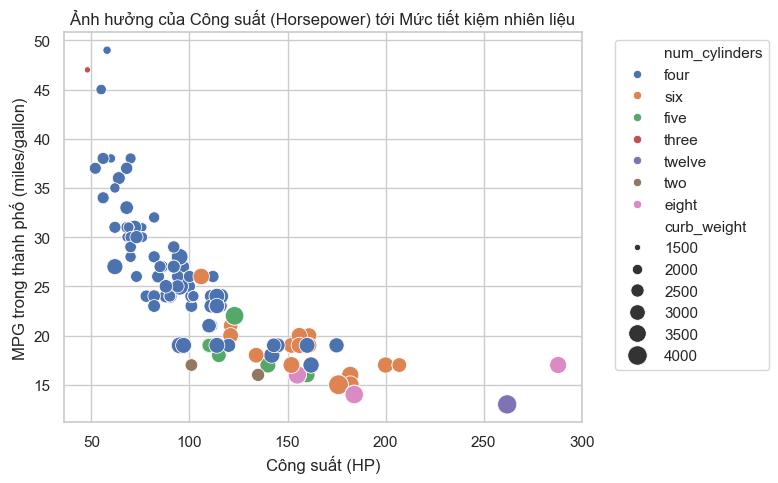

In [25]:
# TODO M2.6: biểu đồ tự chọn
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='horsepower', y='city_mpg', hue='num_cylinders', size='curb_weight', sizes=(20, 200))
plt.title("Ảnh hưởng của Công suất (Horsepower) tới Mức tiết kiệm nhiên liệu")
plt.xlabel("Công suất (HP)")
plt.ylabel("MPG trong thành phố (miles/gallon)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Nhận xét:** 
Xe có mã lực cao thì mức tiêu thụ nhiên liệu trong thành phố càng tệ (MPG giảm rõ rệt theo đường cong). Những xe này thường có số xi-lanh lớn (six, eight) và khối lượng (curb_weight) rất nặng.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

**Phát hiện chính:**
1. Dung tích động cơ (engine_size) và công suất (horsepower) là hai yếu tố quyết định mạnh nhất đến giá xe (Tương quan thuận rất mạnh).
2. Thị trường xe trong dataset phân hóa mạnh: Đa số là xe giá rẻ (hatchback/sedan), và nhóm nhỏ xe cao cấp kéo lệch phân phối giá về bên phải.
3. Đánh đổi sức mạnh và tính kinh tế: Xe có sức mạnh cao thì có chỉ số hiệu năng nhiên liệu (city/highway mpg) rất thấp, hao xăng hơn nhiều.

**Hạn chế của dataset:**
1. Lượng mẫu quá nhỏ (~200 dòng), các nhóm như xe động cơ diesel hay kiểu dáng convertible bị thiếu hụt mẫu cực trọng, dễ gây bias.
2. Dữ liệu bị thiếu (missing values) nhiều ở các cột quan trọng như `normalized_losses`, khiến việc phân tích rủi ro bảo hiểm không toàn diện.

**Ví dụ Correlation != Causation:**
Kích thước xe (length/width) có tương quan thuận rất cao với giá xe. Tuy nhiên, việc cố tình chế tạo thân xe to ra không trực tiếp làm giá xe tăng lên (nó không phải nguyên nhân cốt lõi). Giá trị thực sự nằm ở việc xe lớn thường được các hãng định vị vào phân khúc sang trọng, nhồi nhét động cơ to và nhiều công nghệ đắt tiền bên trong.

**Câu hỏi mở rộng:**
Hệ dẫn động (drive_wheels: fwd, rwd, 4wd) kết hợp với vị trí đặt động cơ (engine_location) có tác động thế nào đến mức đánh giá rủi ro (symboling)?